In [8]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

import hist.intervals

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
#coffea output file
f_sig = "../coffea/corrected_sig_2022/ERE.coffea"
#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
sig_histo.keys()

dict_keys(['gen_vxy1', 'gen_vxy10', 'gen_vxy100', 'gen_ele_pt', 'gen_ele_eta', 'gen_ele_phi', 'gen_ele_dR', 'gen_ele_vxy1', 'gen_ele_vxy10', 'gen_ele_vxy100', 'match_ele_gen_pt', 'match_ele_gen_vxy1', 'match_ele_gen_vxy10', 'match_ele_gen_vxy100', 'gen_ele_pt_vs_vxy1', 'match_ele_gen_pt_vs_vxy1', 'PFMET', 'PFMET_vs_genMET', 'cutDesc', 'cutflow', 'cutflow_cts', 'cutflow_nevts', 'cutflow_vtx_matched'])

Saved: ./plots/signal_2018/ptvslxy.png
count_den: [[6.463e+03 8.870e+02 1.830e+02 5.100e+01 1.500e+01]
 [2.620e+03 5.970e+02 1.290e+02 4.400e+01 1.900e+01]
 [4.000e+02 1.310e+02 3.600e+01 1.400e+01 4.000e+00]
 [6.600e+01 1.700e+01 4.000e+00 2.000e+00 2.000e+00]]
4
edges_den0: [ 0.  5. 10. 15. 20.]
edges_den1: [ 0.  4.  8. 12. 16. 20.]


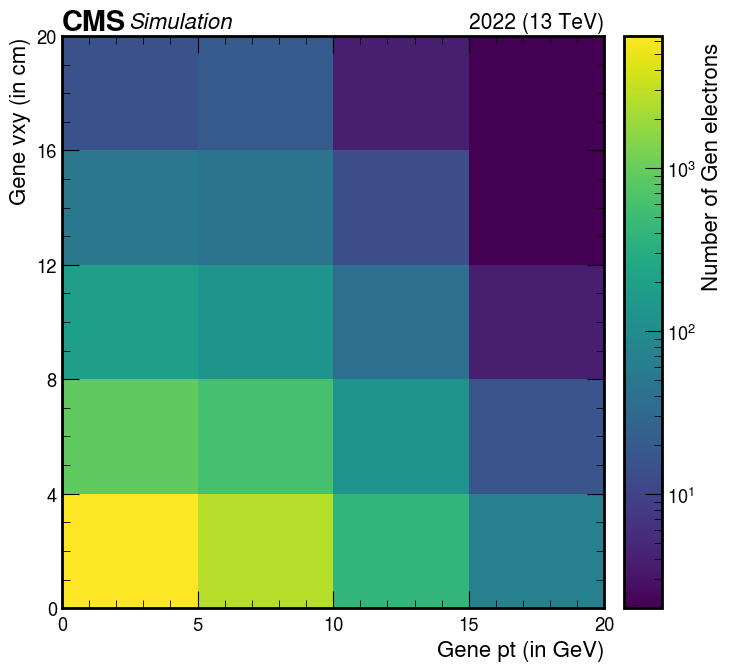

In [10]:
m1 = 20
delta = 0.1
ctau = 10

# Plot settings
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {
    'variable': 'gen_ele_pt_vs_vxy1',
    'cut': 'cut0',
    'year': 2022
}

style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': "Gene vxy (in cm)",   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': 'Number of Gen electrons ',   
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}

count_den, edges_den0, edges_den1=ptools.plot_signal_2D_match(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict, match_type='L', passID=1)
#ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
#ptools.plot_signal_2D_match(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict, match_type='L', passID=1)
print ("count_den:", count_den)
print (len(count_den))
print ("edges_den0:", edges_den0)  #xlim: pT here
print ("edges_den1:", edges_den1)  #ylim: vxy here

#vxy1 has  abin width of 4
#pt bin width is 5

Saved: ./plots/signal_2018/ptvslxy.png
count_num: [[4.507e+03 5.310e+02 9.300e+01 2.300e+01 4.000e+00]
 [1.593e+03 3.860e+02 1.050e+02 3.300e+01 1.400e+01]
 [2.540e+02 9.400e+01 3.500e+01 1.200e+01 3.000e+00]
 [4.300e+01 1.100e+01 2.000e+00 2.000e+00 2.000e+00]]
edges_num0: [ 0.  5. 10. 15. 20.]
edges_num1: [ 0.  4.  8. 12. 16. 20.]


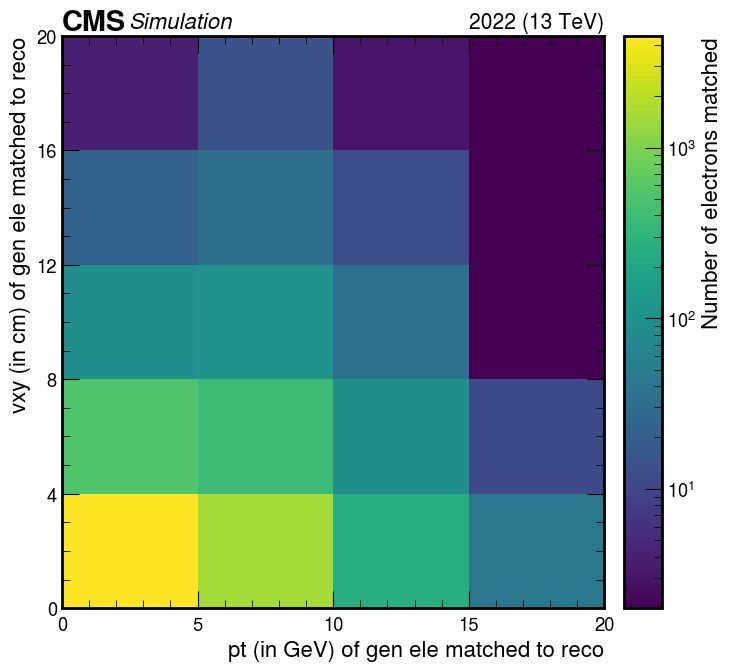

In [11]:
m1 = 20
delta = 0.1
ctau = 10

# Plot settings
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {
    'variable': 'match_ele_gen_pt_vs_vxy1',
    'cut': 'cut0',
    'year': 2022
}

style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "pt (in GeV) of gen ele matched to reco",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': "vxy (in cm) of gen ele matched to reco",   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': 'Number of electrons matched',   
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}

count_num, edges_num0, edges_num1=ptools.plot_signal_2D_match(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict, match_type='L', passID=1)

print ("count_num:", count_num)
print ("edges_num0:", edges_num0)
print ("edges_num1:", edges_num1)

In [12]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_R, unc_eff_R = eff_determine_unc(count_num, count_den)

print (efficiency_R)
print (efficiency_R.shape)

print (len(efficiency_R))


[[0.69735417 0.59864713 0.50819672 0.45098039 0.26666667]
 [0.60801527 0.64656616 0.81395349 0.75       0.73684211]
 [0.635      0.71755725 0.97222222 0.85714286 0.75      ]
 [0.65151515 0.64705882 0.5        1.         1.        ]]
(4, 5)
4


In [13]:
# print ("len(count_den):", len(count_den))
# print ("len(count_num):", len(count_num))
# print (len(edges_den))
# print (len(edges_num))

# print (efficiency_R.shape)

Text(0.5, 1.0, '(m1,dm)=(20,2) GeV, Lpt matched')

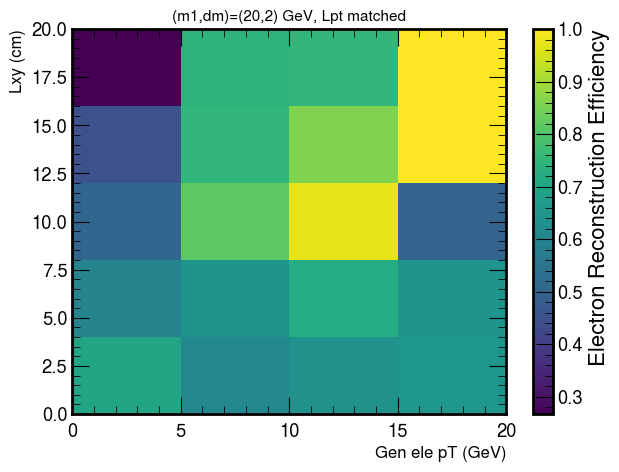

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.pcolormesh(edges_num0,edges_num1, efficiency_R.T)
plt.colorbar(label="Electron Reconstruction Efficiency")


plt.xlabel("Gen ele pT (GeV)",fontsize=12)
plt.ylabel("Lxy (cm)",fontsize=12)
plt.title("(m1,dm)=(20,2) GeV, Lpt matched", fontsize=11)